In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

# Using _trajectory-container-tools_ with Panda `DataFrame`

## Import trajectory-container-tools namespace

In [2]:
import trajectory_container_tools as tct

## Import dataframe

In [3]:
dataset_path = "data/repository_data/tests_data/dataframe_test_data/marmotte/ga_hard_snow_25_01_a/slip_dataset_all.pkl"
dataset_snow, dataset_real_path = tct.extractor.unpack_dataframe_and_show_topic(dataset_path)

Using dataframe bag: /ros2_ws/src/trajectory-container-tools/data/repository_data/tests_data/dataframe_test_data/marmotte/ga_hard_snow_25_01_a/slip_dataset_all.pkl
Available column label:
   init_icp_x  init_icp_y  init_icp_z  init_icp_roll  init_icp_pitch  \
0         0.0         0.0         0.0            0.0             0.0   
1         0.0         0.0         0.0            0.0             0.0   
2         0.0         0.0         0.0            0.0             0.0   
3         0.0         0.0         0.0            0.0             0.0   
4         0.0         0.0         0.0            0.0             0.0   

   init_icp_yaw  calib_step  cmd_left_0  cmd_right_0  cmd_left_1  ...  \
0           0.0         0.0    0.000000     0.000000    6.337527  ...   
1           0.0         0.0    6.337527     6.558533    6.337527  ...   
2           0.0         0.0    6.337527     6.558533    6.337527  ...   
3           0.0         1.0   -5.933710     5.305197   -5.933710  ...   
4           0.

### Requirement:
The dataframe must contain one trajectory or a batch of trajectories (one per row) with some features (column) containing a timestep index in there name e.g., `feature_1`, `feature_2` ...

In [4]:
dataset_snow.head()

,init_icp_x,init_icp_y,init_icp_z,init_icp_roll,init_icp_pitch,init_icp_yaw,calib_step,cmd_left_0,cmd_right_0,cmd_left_1,...,body_vel_disturption_yaw_30,body_vel_disturption_yaw_31,body_vel_disturption_yaw_32,body_vel_disturption_yaw_33,body_vel_disturption_yaw_34,body_vel_disturption_yaw_35,body_vel_disturption_yaw_36,body_vel_disturption_yaw_37,body_vel_disturption_yaw_38,body_vel_disturption_yaw_39
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,6.337527,...,0.001605,0.006716,0.017343,0.025290,0.024934,0.020090,0.017515,0.016509,0.017604,0.017604
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.337527,6.558533,6.337527,...,-0.003664,-0.004462,-0.004982,-0.005214,-0.005224,-0.005149,-0.005063,-0.004978,-0.004937,-0.004937
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.337527,6.558533,6.337527,...,0.035404,0.024445,0.005511,-0.011774,-0.021206,-0.026605,-0.019148,-0.010976,-0.002586,-0.002586
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-5.933710,5.305197,-5.933710,...,-0.436207,-0.427349,-0.408820,-0.387365,-0.358591,-0.331346,-0.303292,-0.283153,-0.267858,-0.266377
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-5.933710,5.305197,-5.933710,...,1.415197,1.747023,1.787952,1.410041,0.570877,-0.600815,-1.782877,-2.689737,-2.858565,-2.858565


## 1. Base case

Extract multiple features from a dataset (formated in a dataframe) based on a configuration dictionary.

The `features_config` specify the feature name to lookout in the `dataset_frame` header and agregate them in a `Multifeature` dataclass. Feature dimensions such as 'x', 'y' 'z' are specified either by using existing `AbstractFeatureDataclass` subclass such as: `StatePose2D`, `CmdStandard`, `CmdSkidSteer`, `Velocity`, `VelocitySkidSteer` or by using tuple of strings such as `('<new feature dataclass type name>', '<dimension names 1>', '<dimension names 2>', ...)`.

```python
feature_config = {
    'icp_interpolated': StatePose2D,
    'idd_vel':          StatePose2D,
    'icp':              ('StatePose3D', 'x', 'y', 'z', 'roll', 'pitch', 'yaw')
}
```

Note that each `AbstractFeatureDataclass` subclass validate that each dimension have uniform shape and have monotonic increassing timestep index without skip.


In [5]:
from trajectory_container_tools.dataclasses import StatePose2D

mf1 = tct.extractor.from_dataframe(dataset_snow,
                         dataset_info="Robot: marmotte, Details: ga_hard_snow_25_01_a",
                         features_config={
                             'body_vel_disturption': StatePose2D,
                             'icp_interpolated': StatePose2D,
                             'icp_vel': StatePose2D,
                             'idd_vel': StatePose2D,
                             'icp':     ('StatePose3D', 'x', 'y', 'z', 'roll', 'pitch', 'yaw')
                         },
                         header_mix_label_and_timesteps=True)

print(mf1)


Multifeature(
   dataset_info: Robot: marmotte, Details: ga_hard_snow_25_01_a
   aggregated_date: 2025-09-29 02:17:31.400499
   body_vel_disturption: 
          StatePose2D(
             feature_name: body_vel_disturption
             trajectory_len: 40
             batch: True
             transposed: False
             dimensions:
                timesteps_indices: (ndarray) shape (40,) range 0 ⟶ 39
                x: (ndarray) shape (309, 40) range -2.125760863682185 ⟶ 2.446234838069336
                y: (ndarray) shape (309, 40) range -2.1924347573561866 ⟶ 1.1001163567627252
                yaw: (ndarray) shape (309, 40) range -3.4816131848932867 ⟶ 2.8881285042196287
          )
   icp_interpolated: 
          StatePose2D(
             feature_name: icp_interpolated
             trajectory_len: 40
             batch: True
             transposed: False
             dimensions:
                timesteps_indices: (ndarray) shape (40,) range 0 ⟶ 39
                x: (ndarray) shape


## 2. Case requiring post-processing

1. Just create a new dataclass inheriting from a `AbstractFeatureDataclass` subclass e.g. `StatePose2D`
2. Overide `post_init_feature_callback` with the desired post-processing process

In [6]:
steady_state_mask = dataset_snow['steady_state_mask'].to_numpy() == True

@dataclass
class StatePose2DSteadyState(StatePose2D):

    def post_init_feature_callback(self, feature_name):
        # Example for creating an explicit timestep t=0 property named "<feature_name>_init"
        feature = self.get_dynamic_field(feature_name)
        if isinstance(feature, np.ndarray):
            if self.batch:
                # Case batch data
                feature_ini = feature[:, 0, ...]
            else:
                # Case time-serie data
                feature_ini = feature[0, ...]
            self.set_dynamic_field(f"{feature_name}_init", feature_ini)
        return None

In [7]:
mfs = tct.extractor.from_dataframe(
        dataset_snow,
        dataset_info="Robot: marmotte, Details: ga_hard_snow_25_01_a, STEADY STATE",
        features_config={
            'body_vel_disturption': StatePose2DSteadyState,
            'icp_interpolated': StatePose2DSteadyState,
            'icp_vel': StatePose2DSteadyState,
            'idd_vel': StatePose2DSteadyState,
        },
        header_mix_label_and_timesteps=True)

## 3. Accessing Data

### You can print the summary of the data container
Dataframe data can be accessed through the structured dataclass attributes. Each message type provides access to its specific fields.

In [8]:
print(mfs)
# or using the convenient method
# mfs.summary


Multifeature(
   dataset_info: Robot: marmotte, Details: ga_hard_snow_25_01_a, STEADY STATE
   aggregated_date: 2025-09-29 02:17:31.920856
   body_vel_disturption: 
          StatePose2DSteadyState(
             feature_name: body_vel_disturption
             trajectory_len: 40
             batch: True
             transposed: False
             dimensions:
                timesteps_indices: (ndarray) shape (40,) range 0 ⟶ 39
                x: (ndarray) shape (309, 40) range -2.125760863682185 ⟶ 2.446234838069336
                y: (ndarray) shape (309, 40) range -2.1924347573561866 ⟶ 1.1001163567627252
                yaw: (ndarray) shape (309, 40) range -3.4816131848932867 ⟶ 2.8881285042196287
                x_init: (ndarray) shape (309,) range -0.6133663809584959 ⟶ 1.002941617315022
                y_init: (ndarray) shape (309,) range -0.6149736406466674 ⟶ 0.4951355772735057
                yaw_init: (ndarray) shape (309,) range -2.0632824878223532 ⟶ 2.7472066788883858
          

## You can access each features and their dimension by property call

In [9]:
mfs.idd_vel.x.shape == mfs.icp_vel.x.shape == mfs.body_vel_disturption.x.shape

True

## You can print the summary of any data container features

In [10]:
print(mfs.body_vel_disturption)


          StatePose2DSteadyState(
             feature_name: body_vel_disturption
             trajectory_len: 40
             batch: True
             transposed: False
             dimensions:
                timesteps_indices: (ndarray) shape (40,) range 0 ⟶ 39
                x: (ndarray) shape (309, 40) range -2.125760863682185 ⟶ 2.446234838069336
                y: (ndarray) shape (309, 40) range -2.1924347573561866 ⟶ 1.1001163567627252
                yaw: (ndarray) shape (309, 40) range -3.4816131848932867 ⟶ 2.8881285042196287
                x_init: (ndarray) shape (309,) range -0.6133663809584959 ⟶ 1.002941617315022
                y_init: (ndarray) shape (309,) range -0.6149736406466674 ⟶ 0.4951355772735057
                yaw_init: (ndarray) shape (309,) range -2.0632824878223532 ⟶ 2.7472066788883858
          )


## Simplify your code and minimize risk of piping the wrong data

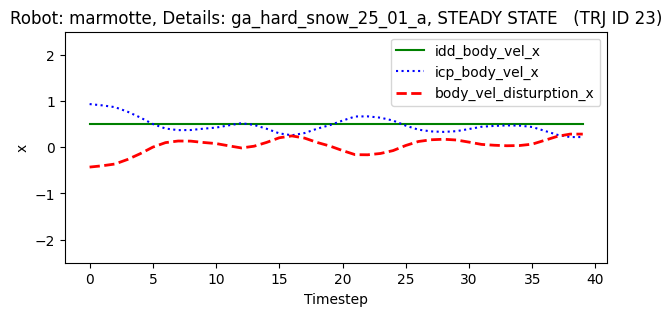

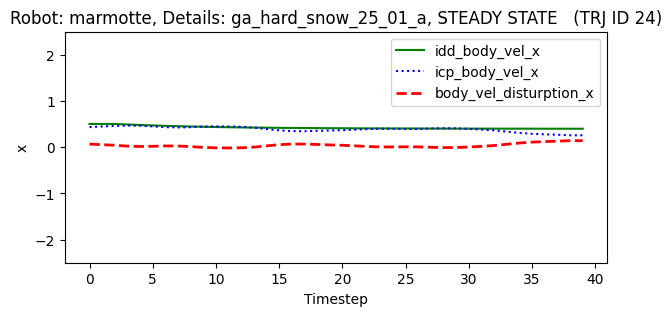

In [11]:
def plot_dataset_trajectory_steady_state_x_array(trajectory_id: int, title: str, y_label:str, ylim: tuple=(-2.5, 2.5)):
    fig = plt.figure(num=None, figsize=(7,3), dpi=None, facecolor=None, edgecolor=None)
    plt.title(f'{title}   (TRJ ID {trajectory_id})')
    plt.plot(mfs.idd_vel.x[trajectory_id, :], label="idd_body_vel_x", color="green")
    plt.plot(mfs.icp_vel.x[trajectory_id, :], label="icp_body_vel_x", color="blue", linestyle="dotted")
    plt.plot(mfs.body_vel_disturption.x[trajectory_id, :], label="body_vel_disturption_x", color="red", linestyle="dashed", linewidth="2.")
    plt.legend()
    plt.ylabel(y_label)
    plt.xlabel('Timestep')
    plt.ylim(*ylim)
    return None

_ids = range(23,25)
for _trj_id in _ids:
    plot_dataset_trajectory_steady_state_x_array(trajectory_id=_trj_id, title=mfs.dataset_info, y_label="x", ylim=(-2.5, 2.5))

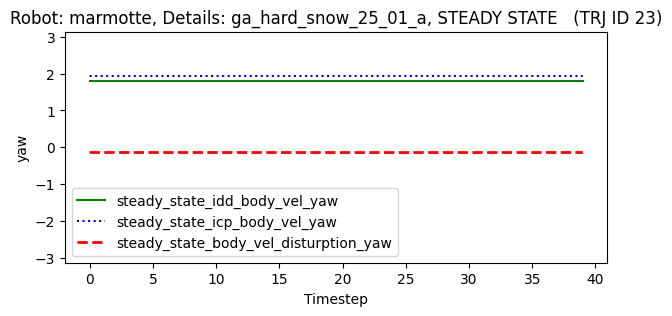

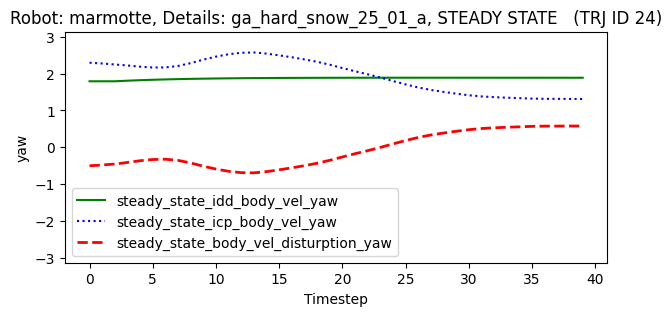

In [12]:
def plot_dataset_trajectory_steady_state_yaw(trajectory_id: int, title: str, y_label:str, ylim: tuple=(-2.5, 2.5)):
    fig = plt.figure(num=None, figsize=(7,3), dpi=None, facecolor=None, edgecolor=None)
    plt.title(f'{title}   (TRJ ID {trajectory_id})')
    plt.plot(mfs.idd_vel.yaw[trajectory_id, :], label="steady_state_idd_body_vel_yaw", color="green")
    plt.plot(mfs.icp_vel.yaw[trajectory_id, :], label="steady_state_icp_body_vel_yaw", color="blue", linestyle="dotted")
    plt.plot(mfs.body_vel_disturption.yaw[trajectory_id, :], label="steady_state_body_vel_disturption_yaw", color="red", linestyle="dashed", linewidth="2.")
    plt.legend()
    plt.ylabel(y_label)
    plt.xlabel('Timestep')
    plt.ylim(*ylim)
    return None

# _ids = [29,30,31,32]
_ids = range(23,25)
for _trj_id in _ids:
    plot_dataset_trajectory_steady_state_yaw(trajectory_id=_trj_id, title=mfs.dataset_info, y_label="yaw", ylim=(-3.1416, 3.1416))